In [43]:
import os
import globals as gl
import rsatoolbox as rsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
plt.style.use('default')

In [44]:
experiment = 'smp2'
glm = 12

# load all rdms
rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'glm{glm}.ROI.hdf5'))

N = len(np.unique(rdms.rdm_descriptors['sn']))

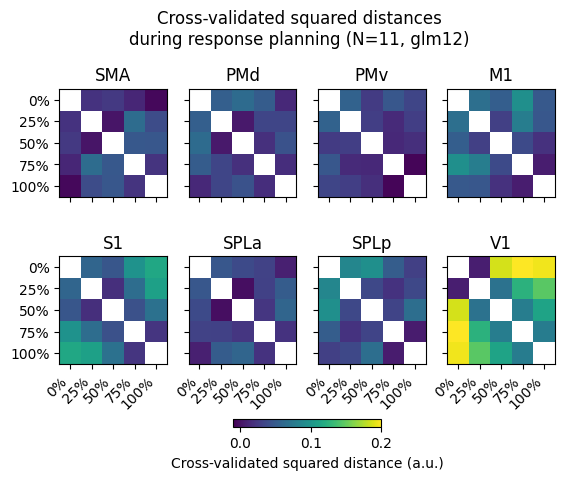

In [45]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

rdmsL_planning = rdms.subset('Hem', [Hem])
rdmsL_planning = rdmsL_planning.subset_pattern('conds', ['0%', '25%', '50%', '75%', '100%'])
rdmsL_planning = rdmsL_planning.mean(axis='sn')

vmin, vmax = -.01, .2

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    row = r // 4
    col = r % 4

    rdm = rdmsL_planning.subset('ROI', [roi])

    cax = rsa.vis.show_rdm_panel(
            rdm, axs[row, col], rdm_descriptor='ROI', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdm.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdm.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdm.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)

    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated squared distance (a.u.)')

fig.suptitle(f'Cross-validated squared distances\nduring response planning (N={N}, glm{glm})')

plt.show()
# rsa.vis.show_rdm(rdms)

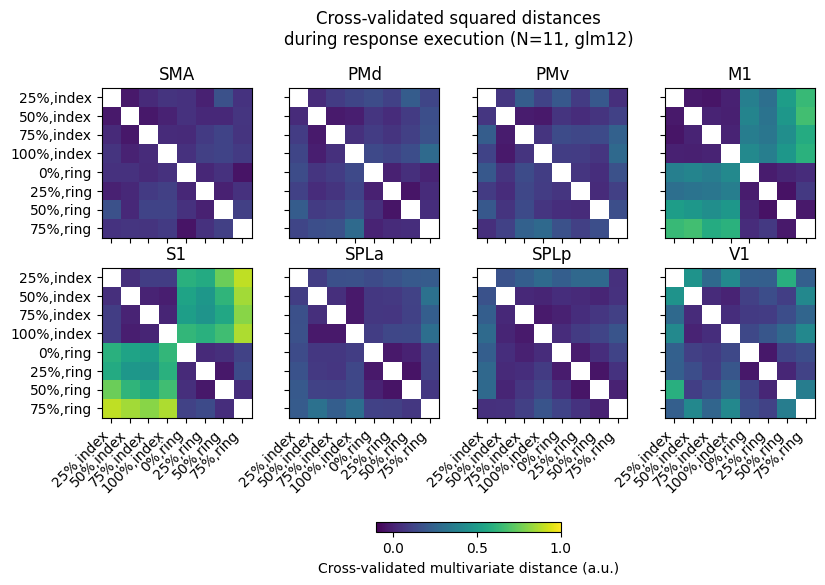

In [46]:
rdmsL_execution = rdms.subset('Hem', [Hem])
rdmsL_execution = rdmsL_execution.subset_pattern('conds', ['25%,index', '50%,index', '75%,index', '100%,index',
                                                           '0%,ring', '25%,ring', '50%,ring', '75%,ring'])
rdmsL_execution = rdmsL_execution.mean(axis='sn')

vmin, vmax = -.1, 1

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))

for r, roi in enumerate(rois):
    row = r // 4
    col = r % 4

    rdm = rdmsL_execution.subset('ROI', [roi])

    cax = rsa.vis.show_rdm_panel(
            rdm, axs[row, col], rdm_descriptor='ROI', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdm.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdm.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdm.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)

    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')

fig.suptitle(f'Cross-validated squared distances\nduring response execution (N={N}, glm{glm})')
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.3, top=0.85)

plt.show()

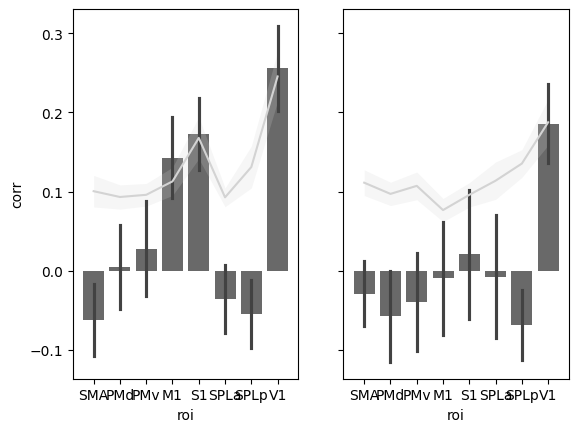

In [47]:
experiment = 'smp2'
atlas = 'ROI'
glm = 12

xval_corr = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'{atlas}.glm{glm}.xval_corr.tsv'), sep='\t')

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)
sns.barplot(data=xval_corr[xval_corr['Hem']=='L'], ax=axs[0], x='roi', y='corr', color='dimgrey', errorbar='se')
sns.lineplot(data=xval_corr[xval_corr['Hem']=='L'], ax=axs[0], x='roi', y='noise_ceiling_corr', color='lightgrey', errorbar='se', err_kws={'lw':0})
sns.barplot(data=xval_corr[xval_corr['Hem']=='R'], ax=axs[1], x='roi', y='corr', color='dimgrey', errorbar='se')
sns.lineplot(data=xval_corr[xval_corr['Hem']=='R'], ax=axs[1], x='roi', y='noise_ceiling_corr', color='lightgrey', errorbar='se', err_kws={'lw':0})

plt.show()

In [48]:
glm = 14
experiment = 'smp2'
rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'glm{glm}.ROI.hdf5'))

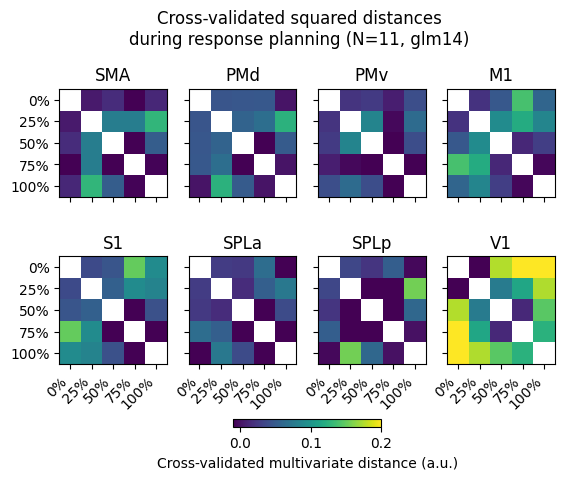

In [49]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

rdmsL_planning = rdms.subset('Hem', [Hem])
rdmsL_planning = rdmsL_planning.subset_pattern('conds', ['0%', '25%', '50%', '75%', '100%'])rdmsL_planning.subset_pattern('conds', ['0%', '25%', '50%', '75%', '100%'])
rdmsL_planning = rdmsL_planning.mean(axis='sn')

vmin, vmax = -.01, .2

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    row = r // 4
    col = r % 4

    rdm = rdmsL_planning.subset('ROI', [roi])

    cax = rsa.vis.show_rdm_panel(
            rdm, axs[row, col], rdm_descriptor='ROI', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdm.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdm.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdm.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)

    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')

fig.suptitle(f'Cross-validated squared distances\nduring response planning (N={N}, glm{glm})')

plt.show()